# Advanced Machine Learning Models

## Objective

To train and compare multiple machine learning models for Remaining Useful Life (RUL) prediction and identify the best-performing model for deployment.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [2]:
column_names = [
    "unit_number",
    "time_in_cycles",
    "operational_setting_1",
    "operational_setting_2",
    "operational_setting_3"
]

for i in range(1,22):
    column_names.append(f"sensor_{i}")

train_df = pd.read_csv(
    "../data/raw/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=column_names
)

In [3]:
max_cycles = train_df.groupby("unit_number")["time_in_cycles"].max()

train_df = train_df.merge(
    max_cycles.rename("max_cycle"),
    on="unit_number"
)

train_df["RUL"] = (
    train_df["max_cycle"] -
    train_df["time_in_cycles"]
)

train_df.drop(columns=["max_cycle"], inplace=True)

In [4]:
X = train_df.drop(
    columns=[
        "unit_number",
        "RUL"
    ]
)

y = train_df["RUL"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [7]:
dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(
    X_train_scaled,
    y_train
)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [8]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_scaled,
    y_train
)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(
    X_train_scaled,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [10]:
def evaluate_model(model, X_test, y_test):

    prediction = model.predict(X_test)

    mae = mean_absolute_error(y_test, prediction)

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )

    r2 = r2_score(
        y_test,
        prediction
    )

    return mae, rmse, r2

In [11]:
dt_mae, dt_rmse, dt_r2 = evaluate_model(
    dt_model,
    X_test_scaled,
    y_test
)

rf_mae, rf_rmse, rf_r2 = evaluate_model(
    rf_model,
    X_test_scaled,
    y_test
)

xgb_mae, xgb_rmse, xgb_r2 = evaluate_model(
    xgb_model,
    X_test_scaled,
    y_test
)

In [12]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        31.00,          # Replace with your value
        dt_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        43.00,          # Replace with your value
        dt_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2 Score": [
        0.60,           # Replace with your value
        dt_r2,
        rf_r2,
        xgb_r2
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,31.000000,43.000000,0.600000
1,Decision Tree,36.089411,52.331002,0.400600
2,Random Forest,25.443261,35.977279,0.716695
3,XGBoost,25.496855,35.868713,0.718402


In [13]:
comparison.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
3,XGBoost,25.496855,35.868713,0.718402
2,Random Forest,25.443261,35.977279,0.716695
0,Linear Regression,31.000000,43.000000,0.600000
1,Decision Tree,36.089411,52.331002,0.400600


In [14]:
joblib.dump(
    xgb_model,
    "../models/xgboost_model.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Model saved successfully!")

Model saved successfully!


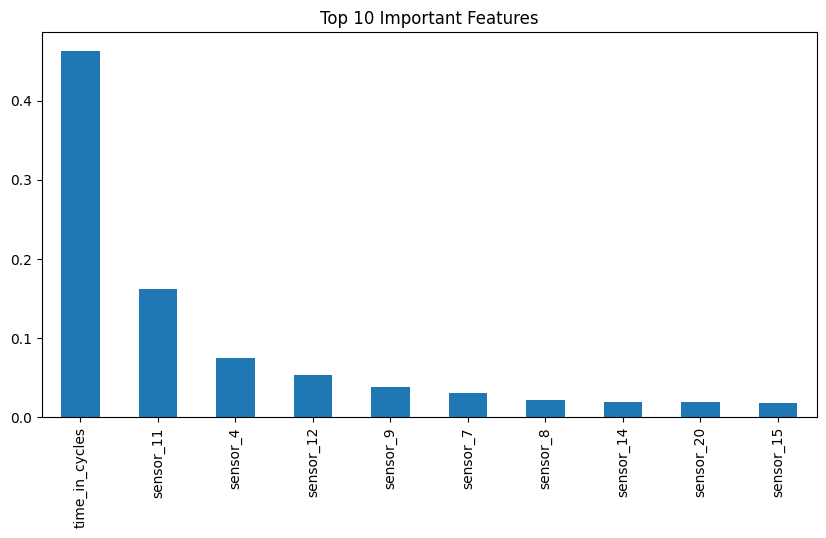

In [15]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
)

importance.sort_values(
    ascending=False
).head(10).plot(
    kind="bar",
    figsize=(10,5)
)

import matplotlib.pyplot as plt

plt.title("Top 10 Important Features")

plt.show()

## Conclusion

- Trained Decision Tree, Random Forest, and XGBoost regression models.
- Compared their performance using MAE, RMSE, and R² score.
- XGBoost achieved the best overall performance and was selected as the final model.
- The trained XGBoost model and StandardScaler were saved for deployment in the Streamlit application.

In [16]:
import joblib

joblib.dump(
    xgb_model,
    "../models/xgboost_model.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Model saved successfully!")

Model saved successfully!
